In [1]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [2]:
DATA_DIR = "titan-hf-5"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Feedline Pressure",
           "pres_3": "PT3 Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure"}

DRIVERS = {0: {"name": "Ox Fill", "false": "Close", "true": "Open"},
           1: {"name": "Ground Vent", "false": "Close", "true": "Open"},
           2: {"name": "Pressurization", "false": "Open", "true": "Close"},
           3: {"name": "Engine Vent", "false": "Close", "true": "Open"},
           4: {"name": "Ignition", "false": "Shutoff", "true": "Ignite"}}

In [3]:
# Manually locating timestamps for events

prep.process_data(DATA_DIR, SENSORS)
from time import time


contents = []
ignition_index = 0
samples_before_ignition = 0

with open(f"{DATA_DIR}/data-raw/console.log", 'r') as file:
    while True:
        line = file.readline()
        if len(line) <= 1:
            break
        contents.append(line)
for message in contents:
    if "Ignition in 10" in message:
        print(message, contents.index(message))
        ignition_index = contents.index(message)
        break
#gets the data log of the number of samples sent to approximate
#the 'start time'
for idx in range(ignition_index,0,-1):
    if "samples obtained" in contents[idx]:
        samples_before_ignition = int(contents[idx].split(':')[2].split()[0])
        temp_index = contents.index(contents[idx])
        message_count = 0
        for i in range(temp_index, ignition_index, 1):
            if "Sending data to" in contents[i]:
                message_count += 1   
        time_since_start_approx = round(samples_before_ignition/300)
        time_since_start = time_since_start_approx + round(message_count/2)
        break


FileNotFoundError: [Errno 2] No such file or directory: 'titan-hf-5/data-raw/raw.csv'

In [4]:
print("Processing events")
# prep.process_events(DATA_DIR, DRIVERS)
print("Processing data")
prep.process_data(DATA_DIR, SENSORS)
print("Done!")
# 33
# 6509

Processing events
Processing data


FileNotFoundError: [Errno 2] No such file or directory: 'titan-hf-5/data-raw/raw.csv'

In [5]:
# events = prep.import_events(DATA_DIR)
# print(events[52])
events = [{'secs': str(5456.133330-5), 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': str(5456.133330+15), 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
labels, data = prep.import_data(DATA_DIR, events)
print(labels)
times = data[:, 0]

# data[:,1] = data[:,1] + 150

print(times)

print(f"HF5 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

['Time (s)' 'LC1 Axial Load' 'PT1 Combustion Chamber Pressure'
 'PT2 Feedline Pressure' 'PT3 Injector Pressure' 'PT4 Ox-Tank Pressure']
[0.00000000e+00 3.33000000e-03 6.67000000e-03 ... 5.47112667e+03
 5.47113000e+03 5.47113333e+03]
HF5 Data Summary 
----------------- 
 Sensors: 5 
 Samples: 1641341 
 Events:  2


In [6]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=10, window="blackman")

5451.13333
1635340
[-152.11803 -156.07031 -160.0221  ...  -79.66659  -74.39754  -80.98386]


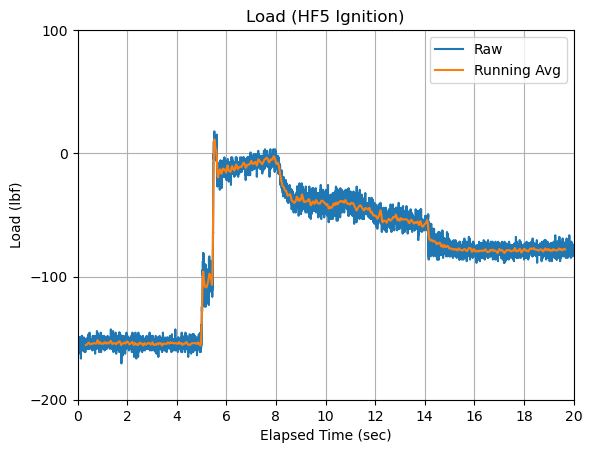

In [7]:
ep.plot(sensor_id=1, event_id=0, duration=20, filter=lpf,
        title="Load (HF5 Ignition)", ylabel="Load (lbf)",
        num_xticks=11, dif_yticks=100)

5451.13333
1635340
[-152.11803 -156.07031 -160.0221  ...  -79.66659  -74.39754  -80.98386]


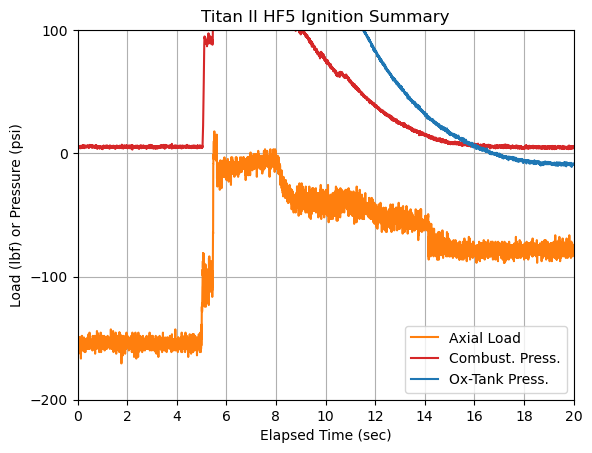

In [8]:
ep.plot(sensor_id=1, event_id=0, duration=20, filter=None,
        title="Titan II HF5 Ignition Summary", ylabel="Load (lbf) or Pressure (psi)",
        legend="Axial Load", num_xticks=11, dif_yticks=100, color="tab:orange")
ep.add_curve(sensor_id=2, event_id=0, duration=20, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=5, event_id=0, duration=20, legend="Ox-Tank Press.", 
             color="tab:blue")
plt.show()

In [9]:
from hmac import new
import csv
from scipy import signal

time_start = float(events[0]["secs"])
time_end = time_start + 20
sample_start = vis.nearest_sample(data, time_start)
sample_end = vis.nearest_sample(data, time_end)
print(len(data[sample_start:sample_end]))

new_time_start = time_start+4
new_time_end = time_start + 14
new_sample_start = vis.nearest_sample(data, new_time_start)
new_sample_end = vis.nearest_sample(data, new_time_end)
truncated_times = data[new_sample_start:new_sample_end,0]
truncated_times = np.reshape(truncated_times,(truncated_times.shape[0],1))
truncated_thrust = data[new_sample_start:new_sample_end,1]
new_times_event = [t - time_start for t in times[new_sample_start:new_sample_end]]
filtered_thrust = lpf.apply(truncated_thrust)
filtered_thrust = np.reshape(filtered_thrust,(filtered_thrust.shape[0],1))
print(filtered_thrust.shape)
print(truncated_times.shape)
filtered_data = np.concatenate((truncated_times,filtered_thrust), axis=1)
times_event = [t - time_start for t in times[sample_start : sample_end]]
data_event = data[sample_start : sample_end, 1]
with open('truncated.csv', 'w',newline='') as csvfile:
    wr = csv.writer(csvfile)
    wr.writerows(filtered_data)
offset = np.mean(data_event[0:1081])

impulse_total = 0
for sample in data_event[1081:]:
    impulse_total += (sample - offset) / 300

impulse_main = 0
for sample in data_event[1081:3915]:
    impulse_main += (sample - offset) / 300

peak_thrust = max(data_event) - offset
peak_sustained_thrust = np.mean(data_event[int(300*6.25) : int(300*6.3)]) - offset
avg_thrust = impulse_main / ((3915 - 1081) / 300)

print(f"Peak Thrust:\t\t  {peak_thrust:.2f}  lbf")
print(f"Peak Sustained Thrust:\t   {peak_sustained_thrust:.2f}  lbf")
print(f"Avg Thrust @ Supersonic:   {avg_thrust:.2f}  lbf")
print(f"Impulse @ Supersonic:\t  {impulse_main:.2f}  lb-sec")
print(f"Total Impulse:\t\t  {impulse_total:.2f}  lb-sec")

6000
(3000, 1)
(3000, 1)
Peak Thrust:		  172.22  lbf
Peak Sustained Thrust:	   141.66  lbf
Avg Thrust @ Supersonic:   101.84  lbf
Impulse @ Supersonic:	  962.04  lb-sec
Total Impulse:		  1518.66  lb-sec


Max estimated thrust: 701.763545802 lbf


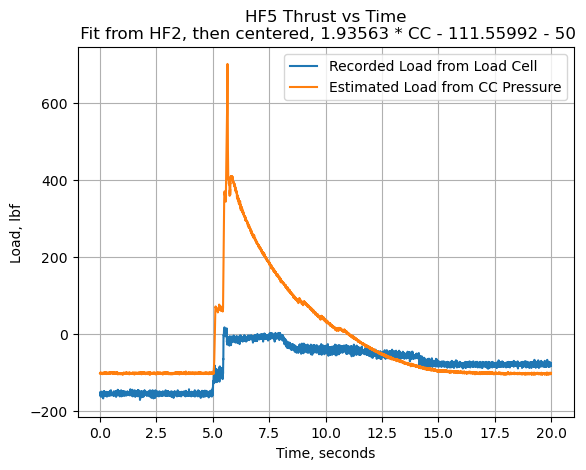

In [41]:
# Manually apply CC-to-thrust curve from HF2 to CC data to check load cell

# Much of this is taken from EventPlotter
from visualization import nearest_sample
event_id = 0
duration = 20
time_start = float(events[event_id]["secs"])
# print(time_start)
time_end = time_start + duration
sample_start = nearest_sample(data, time_start)
# print(sample_start)
sample_end = nearest_sample(data, time_end)
# print(sample_end)

# Separate out our independent and dependent variables
event_times = data[sample_start : sample_end, 0] - time_start

thrust_data = data[sample_start : sample_end, 1]
cc_data = data[sample_start : sample_end, 2]

thrust_from_cc = cc_data * 1.93563 - 111.55992 
# thrust_from_cc -= 50  # Manually correcting to match zero value

print(f"Max estimated thrust: {np.max(thrust_from_cc)} lbf")

plt.plot(event_times, thrust_data, label="Recorded Load from Load Cell")
# plt.plot(event_times, cc_data)
plt.plot(event_times, thrust_from_cc, label="Estimated Load from CC Pressure")
plt.title("HF5 Thrust vs Time\n Fit from HF2, then centered, 1.93563 * CC - 111.55992")
plt.grid()
plt.xlabel("Time, seconds")
plt.ylabel("Load, lbf")
plt.legend()
s